# K-Means Clustering

link for the dataset : https://archive.ics.uci.edu/dataset/502/online+retail+ii


In [145]:

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import openpyxl

pd.set_option('display.max_columns', 999)

## Data Exploration 

In [146]:
# loading data 
df = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2009-2010")


In [147]:
# Prompt: For all columns, show how many non-nulls vs nulls we have, the datatype, and the number of distinct values.

df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')

summary = pd.DataFrame({
    'dtype':           df.dtypes,
    'non_nulls':       df.notnull().sum(),
    'nulls':           df.isnull().sum(),
    'null_%':          (df.isnull().sum() / len(df) * 100).round(2),
    'distinct_values': df.nunique()
})

summary

,dtype,non_nulls,nulls,null_%,distinct_values
Invoice,object,525461,0,0.00,28816
StockCode,object,525461,0,0.00,4632
Description,object,522533,2928,0.56,4681
Quantity,int64,525461,0,0.00,825
InvoiceDate,datetime64[us],525461,0,0.00,25296
Price,float64,525461,0,0.00,1606
Customer ID,float64,417534,107927,20.54,4383
Country,str,525461,0,0.00,40


In [148]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [149]:
df.describe(include='O')

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [150]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [151]:
# looking at null customer id rows 
df[df['Customer ID'].isna()].describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,107927.0,107927,104999,107927.000000,107927,107927.000000,0.0,107927
unique,5229.0,4407,3947,NaN,NaN,NaN,NaN,13
top,537434.0,DOT,DOTCOM POSTAGE,NaN,NaN,NaN,NaN,United Kingdom
freq,675.0,736,735,NaN,NaN,NaN,NaN,106429
mean,NaN,NaN,NaN,0.971045,2010-06-18 13:23:58.586822,7.788750,NaN,NaN
min,NaN,NaN,NaN,-9600.000000,2009-12-01 10:52:00,-53594.360000,NaN,NaN
25%,NaN,NaN,NaN,1.000000,2010-02-22 15:39:00,1.660000,NaN,NaN
50%,NaN,NaN,NaN,1.000000,2010-06-23 14:49:00,3.360000,NaN,NaN
75%,NaN,NaN,NaN,2.000000,2010-10-21 18:01:00,5.910000,NaN,NaN
max,NaN,NaN,NaN,10200.000000,2010-12-09 17:25:00,25111.090000,NaN,NaN


### invoice column

In [152]:
## looking at all this lets just -
# 1. drop the rows with null customer id's
df = df.dropna(subset=['Customer ID'])


In [153]:
df.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,417534.0,417534,417534,417534.000000,417534,417534.000000,417534.000000,417534
unique,23587.0,4031,4459,NaN,NaN,NaN,NaN,37
top,500356.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,270.0,3245,3245,NaN,NaN,NaN,NaN,379423
mean,NaN,NaN,NaN,12.758815,2010-07-01 01:12:19.787610,3.887547,15360.645478,NaN
min,NaN,NaN,NaN,-9360.000000,2009-12-01 07:45:00,0.000000,12346.000000,NaN
25%,NaN,NaN,NaN,2.000000,2010-03-26 11:26:00,1.250000,13983.000000,NaN
50%,NaN,NaN,NaN,4.000000,2010-07-08 19:12:00,1.950000,15311.000000,NaN
75%,NaN,NaN,NaN,12.000000,2010-10-14 14:08:00,3.750000,16799.000000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,NaN


In [154]:
# 2. what does the quantity column look like, are there any negative values there? or null values ?
print(df['Quantity'].describe())
print("Nulls:", df['Quantity'].isnull().sum())
print("Negative values:", (df['Quantity'] < 0).sum())
print("Number of rows with negative quantity:", len(df[df['Quantity'] < 0]))


count    417534.000000
mean         12.758815
std         101.220424
min       -9360.000000
25%           2.000000
50%           4.000000
75%          12.000000
max       19152.000000
Name: Quantity, dtype: float64
Nulls: 0
Negative values: 9839
Number of rows with negative quantity: 9839


In [155]:
neg_qty = df[df['Quantity'] < 0]

# do all negative-quantity rows have an Invoice starting with 'C'?
print(neg_qty['Invoice'].astype(str).str.startswith('C').all())

# see any that don't
neg_qty[~neg_qty['Invoice'].astype(str).str.startswith('C')]


True


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [156]:
neg_qty

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.0,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.0,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom


In [157]:
## so every negative quantity row has an invoice starting with 'C', which means they are all returns


In [158]:
invoice_str = df['Invoice'].astype(str)

# 1. are all invoices 6 characters long?
print(invoice_str.str.len().value_counts())

# 2. classify into the two expected patterns: C + 6 digits, or plain 6 digits
is_c_pattern = invoice_str.str.match(r'^C\d{6}$')
is_plain_pattern = invoice_str.str.match(r'^\d{6}$')

print("Matches C-pattern (C + 6 digits):", is_c_pattern.sum())
print("Matches plain 6-digit pattern:", is_plain_pattern.sum())

# 3. anything that matches NEITHER pattern
mask_unexpected = ~is_c_pattern & ~is_plain_pattern
print("Unexpected pattern count:", mask_unexpected.sum())
df[mask_unexpected]

non_c = df[invoice_str.str.match(r'^\d{6}$')]
print("Non-C invoices with negative quantity:", (non_c['Quantity'] < 0).sum())
non_c[non_c['Quantity'] < 0]
# meaning only the C-prefixed invoices have negative quantities, which is what we expect


Invoice
6    407695
7      9839
Name: count, dtype: int64
Matches C-pattern (C + 6 digits): 9839
Matches plain 6-digit pattern: 407695
Unexpected pattern count: 0
Non-C invoices with negative quantity: 0


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


### Stock code column


In [159]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [160]:
#checks on the stock code column
# 1. basic profile
summary


,dtype,non_nulls,nulls,null_%,distinct_values
Invoice,object,525461,0,0.00,28816
StockCode,object,525461,0,0.00,4632
Description,object,522533,2928,0.56,4681
Quantity,int64,525461,0,0.00,825
InvoiceDate,datetime64[us],525461,0,0.00,25296
Price,float64,525461,0,0.00,1606
Customer ID,float64,417534,107927,20.54,4383
Country,str,525461,0,0.00,40


In [161]:

# 2. length distribution
stockcode_str = df['StockCode'].astype(str)
stockcode_str.str.len().value_counts()


StockCode
5     358793
6      56101
7        905
4        837
1        747
2        125
12        26
Name: count, dtype: int64

In [162]:
# 3. pattern check - how many are purely 5-digit numeric vs something else
is_numeric_5 = stockcode_str.str.match(r'^\d{5}$')
print("5-digit numeric:", is_numeric_5.sum())
print("Non-standard:", (~is_numeric_5).sum())

5-digit numeric: 358793
Non-standard: 58741


In [163]:

# 4. what do the non-standard codes actually look like
df[~is_numeric_5]['StockCode'].value_counts()


StockCode
85123A    3245
85099B    1784
82494L    1050
85099F     903
85099C     845
          ... 
90127A       1
37477C       1
90142D       1
90011A       1
79151B       1
Name: count, Length: 1297, dtype: int64

In [164]:
standard = df[df['StockCode'].astype(str).str.match(r'^\d{5}[A-Za-z]?$')]

standard.groupby('StockCode')['Description'].unique()

# pd.set_option('display.max_columns', 999)

StockCode
10002     [INFLATABLE POLITICAL GLOBE ]
10080        [GROOVY CACTUS INFLATABLE]
10109            [BENDY COLOUR PENCILS]
10120                    [DOGGY RUBBER]
10125         [MINI FUNKY DESIGN TAPES]
                      ...              
90214U      [LETTER "U" BLING KEY RING]
90214V      [LETTER "V" BLING KEY RING]
90214W      [LETTER "W" BLING KEY RING]
90214Y      [LETTER "Y" BLING KEY RING]
90214Z      [LETTER "Z" BLING KEY RING]
Name: Description, Length: 4017, dtype: object

In [165]:
## checking for non 5 digit stock codes (definng standard as 5-digit numeric, optionally followed by a single letter)
# 1. isolate all non-standard (non 5-digit-numeric) stock codes
non_standard = df[~df['StockCode'].astype(str).str.match(r'^\d{5}[A-Za-z]?$')]

# 2. see the unique codes + their descriptions + how often they occur
non_standard.groupby('StockCode')['Description'].agg(['first', 'count']).sort_values('count', ascending=False)


,first,count
StockCode,,
POST,POSTAGE,822
M,Manual,650
15056BL,EDWARDIAN PARASOL BLACK,554
79323LP,LIGHT PINK CHERRY LIGHTS,219
C2,CARRIAGE,125
79323GR,GREEN CHERRY LIGHTS,113
D,Discount,97
ADJUST,Adjustment by john on 26/01/2010 16,61
BANK CHARGES,Bank Charges,26


In [166]:
# removing the non-standard stock codes from the dataset for clustering
df = df[df['StockCode'].astype(str).str.match(r'^\d{5}[A-Za-z]?$')]

In [167]:
# now we can look at country and descrption and again see and remove data
#  but for clustering we really only care about the numeric stock codes and their descriptions, 
# so we can ignore the country column for now and later do a holistic data cleaning exercise 



## Data Cleaning 

In [168]:
df.info()

<class 'pandas.DataFrame'>
Index: 414831 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      414831 non-null  object        
 1   StockCode    414831 non-null  object        
 2   Description  414831 non-null  object        
 3   Quantity     414831 non-null  int64         
 4   InvoiceDate  414831 non-null  datetime64[us]
 5   Price        414831 non-null  float64       
 6   Customer ID  414831 non-null  float64       
 7   Country      414831 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.8+ MB


In [169]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,414831.000000,414831,414831.000000,414831.000000
mean,12.818225,2010-07-01 04:22:54.343383,3.024750,15365.849295
min,-9360.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-26 13:05:00,1.250000,13993.000000
50%,5.000000,2010-07-09 09:46:00,1.950000,15311.000000
75%,12.000000,2010-10-14 15:45:00,3.750000,16805.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,101.520227,NaN,4.475279,1678.287726


In [170]:
cleaned_df = df.copy()

In [171]:
# remove the cancelled invoices (those starting with 'C') from the dataset for clustering
# remove the stock codes that are non-standard (not 5-digit numeric, optionally followed by a single letter)
# remove customer ids that are null / NaN
# remove where price is negative or zero
cleaned_df = cleaned_df[~cleaned_df['Invoice'].astype(str).str.startswith('C')]
cleaned_df = cleaned_df[cleaned_df['StockCode'].astype(str).str.match(r'^\d{5}[A-Za-z]?$')]
cleaned_df = cleaned_df.dropna(subset=['Customer ID'])
cleaned_df = cleaned_df[cleaned_df['Price'] > 0]


In [172]:
# When you run .describe() on object/categorical columns (or df.describe(include='all')), 
# pandas adds these extra rows since mean/std/etc. don't apply to non-numeric data:
# top — the most frequently occurring value in that column (the mode).
# freq — how many times that top value occurs.
# Example: for Description, top might be WHITE HANGING HEART T-LIGHT HOLDER and 
# freq might be 2000, meaning that description appears 2000 times — it's the single most common value in the column.
cleaned_df.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,405513.0,405513,405513,405513.000000,405513,405513.000000,405513.000000,405513
unique,18966.0,4003,4429,NaN,NaN,NaN,NaN,37
top,500356.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,269.0,3153,3153,NaN,NaN,NaN,NaN,369743
mean,NaN,NaN,NaN,13.623282,2010-07-01 12:44:56.709205,2.986046,15373.393356,NaN
min,NaN,NaN,NaN,1.000000,2009-12-01 07:45:00,0.030000,12346.000000,NaN
25%,NaN,NaN,NaN,2.000000,2010-03-26 14:29:00,1.250000,14004.000000,NaN
50%,NaN,NaN,NaN,5.000000,2010-07-11 10:28:00,1.950000,15326.000000,NaN
75%,NaN,NaN,NaN,12.000000,2010-10-14 17:23:00,3.750000,16814.000000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000,NaN


In [173]:
cleaned_df.info()

<class 'pandas.DataFrame'>
Index: 405513 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      405513 non-null  object        
 1   StockCode    405513 non-null  object        
 2   Description  405513 non-null  object        
 3   Quantity     405513 non-null  int64         
 4   InvoiceDate  405513 non-null  datetime64[us]
 5   Price        405513 non-null  float64       
 6   Customer ID  405513 non-null  float64       
 7   Country      405513 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [174]:
cleaned_df.describe(include='O')

,Invoice,StockCode,Description,Country
count,405513,405513,405513,405513
unique,18966,4003,4429,37
top,500356,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,269,3153,3153,369743


### how much data have we lost 

In [175]:
original_rows = len(df)
remaining_rows = len(cleaned_df)
lost_rows = original_rows - remaining_rows

print(f"Original rows: {original_rows}")
print(f"Remaining rows: {remaining_rows}")
print(f"Lost rows: {lost_rows}")
print(f"Lost %: {lost_rows / original_rows * 100:.2f}%")


Original rows: 414831
Remaining rows: 405513
Lost rows: 9318
Lost %: 2.25%


In [176]:
# more detailed data loss steps
steps = {}
steps['original'] = len(df)

cleaned_df = df[~df['Invoice'].astype(str).str.startswith('C')]
steps['after_remove_cancelled'] = len(cleaned_df)

cleaned_df = cleaned_df[cleaned_df['StockCode'].astype(str).str.match(r'^\d{5}[A-Za-z]?$')]
steps['after_remove_nonstandard_stockcode'] = len(cleaned_df)

cleaned_df = cleaned_df.dropna(subset=['Customer ID'])
steps['after_remove_null_customerid'] = len(cleaned_df)

cleaned_df = cleaned_df[cleaned_df['Price'] > 0]
steps['after_remove_nonpositive_price'] = len(cleaned_df)

pd.Series(steps).to_frame('rows').assign(
    dropped=lambda x: x['rows'].shift(1) - x['rows']
)

,rows,dropped
original,414831,NaN
after_remove_cancelled,405541,9290.0
after_remove_nonstandard_stockcode,405541,0.0
after_remove_null_customerid,405541,0.0
after_remove_nonpositive_price,405513,28.0



# K means stars here 

### create RFM metrics 

In [177]:
cleaned_df.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom


In [ ]:
# cleaned_df['total_spend'] = cleaned_df['Quantity'] * cleaned_df['Price']
cleaned_df.head(5)



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,total_spend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [183]:
customer_df = cleaned_df.groupby('Customer ID').agg(
    monetary_value=('total_spend', 'sum'),
    frequency=('Invoice', 'nunique'),
    max_date=('InvoiceDate', 'max')
).reset_index()

customer_df

,Customer ID,monetary_value,frequency,max_date
0,12346.0,163.41,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,2221.14,2,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00
...,...,...,...,...
4280,18283.0,641.77,6,2010-11-22 15:30:00
4281,18284.0,411.68,1,2010-10-04 11:33:00
4282,18285.0,377.00,1,2010-02-17 10:24:00
4283,18286.0,1246.43,2,2010-08-20 11:57:00


In [184]:
reference_date = customer_df['max_date'].max() + pd.Timedelta(days=1)
customer_df['recency'] = (reference_date - customer_df['max_date']).dt.days


In [186]:
customer_df = customer_df.drop(columns=['max_date'])


In [188]:
customer_df

,Customer ID,monetary_value,frequency,recency
0,12346.0,163.41,2,165
1,12347.0,1323.32,2,3
2,12348.0,221.16,1,74
3,12349.0,2221.14,2,43
4,12351.0,300.93,1,11
...,...,...,...,...
4280,18283.0,641.77,6,18
4281,18284.0,411.68,1,67
4282,18285.0,377.00,1,296
4283,18286.0,1246.43,2,112


### looking at data distributions 

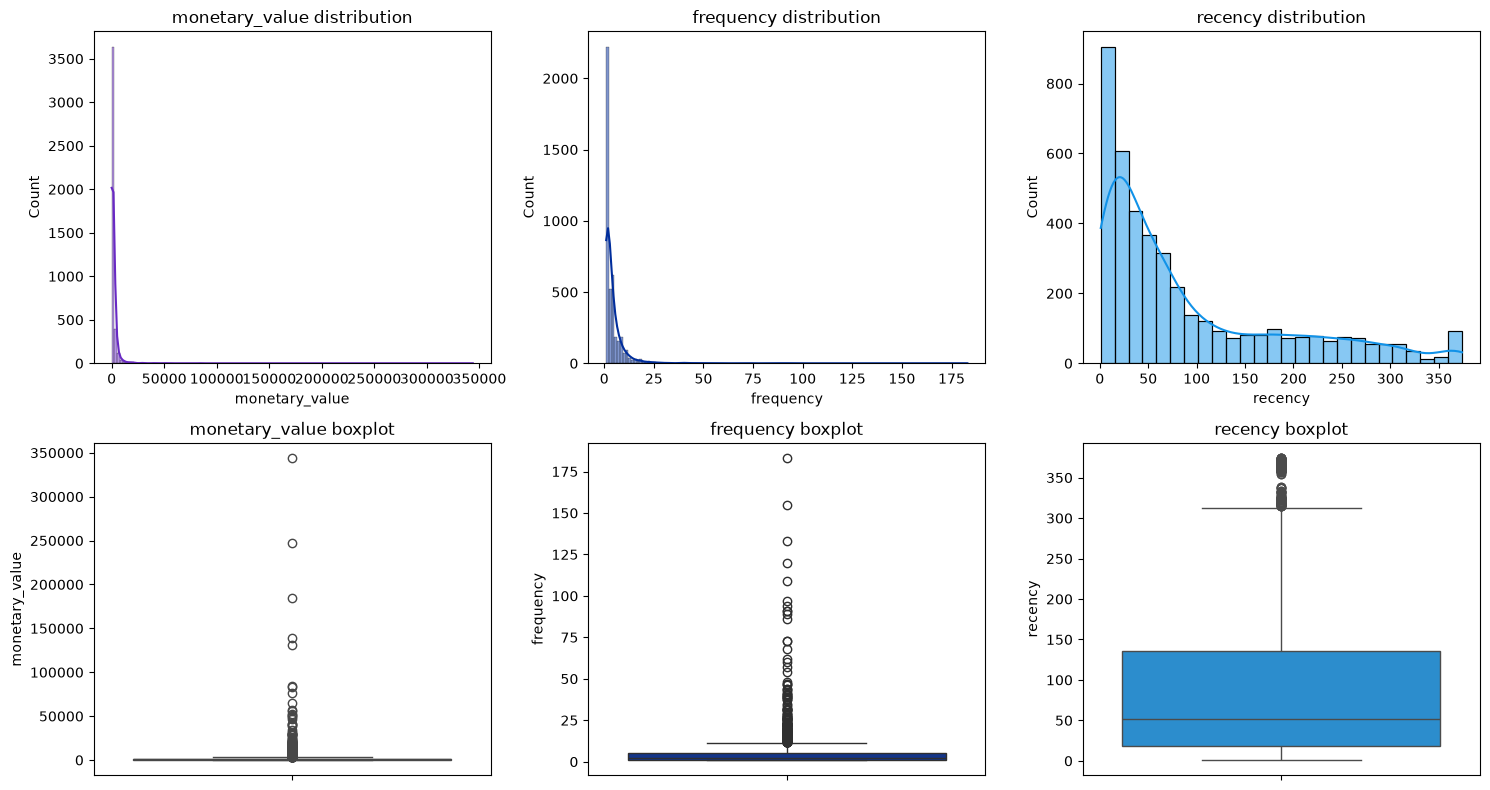

In [ ]:
colors = ['#6929c4', '#002d9c', '#1192e8']
cols = ['monetary_value', 'frequency', 'recency']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(cols):
    sns.histplot(customer_df[col], kde=True, ax=axes[0, i], color=colors[i])
    axes[0, i].set_title(f'{col} distribution')



plt.tight_layout()
plt.show()
